# 1. Business Understanding
The objective of this project is to predict customer churn in a telecom company. By identifying customers likely to leave, the business can take proactive retention measures, reduce revenue loss, and improve customer satisfaction.

**Key Goal:** Build a predictive model to identify churn and derive actionable insights.

# 2. Data Understanding
In this section, we explore the dataset to understand its structure, variables, and quality.

**Focus Areas:**
- Data types and distributions
- Missing values
- Initial patterns and anomalies

# 3. Exploratory Data Analysis (EDA)
EDA is used to uncover patterns, relationships, and insights in the data.

For every visualization, ensure interpretation includes:
- What the pattern shows
- Why it matters
- How it influences modeling decisions

**Examples of insights to highlight:**
- Class imbalance in churn
- Strong predictors (e.g., tenure, charges)
- Correlations between variables

# 4. Data Preparation
This stage involves cleaning and transforming data for modeling.

**Steps include:**
- Handling missing values
- Encoding categorical variables
- Feature scaling
- Feature selection

**Important:** Clearly justify why features are dropped or transformed.

# 5. Modeling
Multiple models are trained to compare performance.

**Models may include:**
- Logistic Regression
- Decision Tree
- Random Forest

**Enhancements:**
- Hyperparameter tuning (e.g., GridSearchCV)
- Cross-validation

# 6. Evaluation
Models are evaluated using appropriate metrics such as:
- Accuracy
- Precision
- Recall
- F1-score

**Key Requirement:**
- Compare models clearly
- Explain why the best model performs better
- Relate results back to business impact (churn reduction)

# 7. Conclusion & Recommendations
Summarize key findings and provide business recommendations.

**Include:**
- Key drivers of churn
- Best performing model
- Actionable strategies (e.g., targeting high-risk customers)

**Business Value:**
Explain how the model can help reduce churn and improve profitability.

# Telecom Customer Churn Prediction
### Phase 3 Machine Learning Project — CRISP-DM Framework

**Author:** Data Science Student  
**Dataset:** Telecom Customer Churn Dataset (3,333 records, 21 features)  
**Target Variable:** `churn` (Boolean — True if customer cancelled service)

---

## Phase 1: Business Understanding

### Real-World Problem

Customer churn — when a customer stops doing business with a company — is one of the most expensive problems in telecommunications. Acquiring a new customer costs **five to seven times more** than retaining an existing one. For a telecom provider managing thousands of accounts, even a modest improvement in retention has a direct, material impact on revenue.

### Stakeholder

The **Customer Retention & Marketing team** at a mid-sized US telecom operator. This team is responsible for proactively reaching out to at-risk customers with targeted offers, service upgrades, or loyalty incentives *before* those customers cancel.

### Why Machine Learning?

A simple rule such as "flag customers with more than 3 service calls" captures one signal but misses the combined, non-linear interactions between usage patterns, plan type, call volume, and account history that a classification model can capture and quantify.

### Business Success Metric

The cost of a **false negative** (missing a real churner) is high — the customer is lost. The cost of a **false positive** (contacting a loyal customer) is low — a wasted retention offer.

> **Primary metric: Recall for the churned class** — catch as many true churners as possible.  
> **Secondary metric: F1-score** — balance recall against precision.  
> **Tertiary metric: ROC-AUC** — evaluate overall ability to rank customers by churn risk.

---
## Phase 2: Data Understanding

In [ ]:
#  Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import squarify
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False
})

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, recall_score, precision_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
# Consistent colour palette used throughout
C_RETAIN = '#2ecc71'   # green  — retained customers
C_CHURN  = '#e74c3c'   # red    — churned customers
C_BLUE   = '#3498db'   # blue   — train / model 1
C_ORANGE = '#e67e22'   # orange — model 2
C_PURPLE = '#9b59b6'   # purple — model 5 / final

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
#  Loading the  dataset and identifying the number of rows and columns
df = pd.read_csv('churn_telecoms_dataset.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 3,333 rows × 21 columns


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
#  Determining the data types and missing values of the dataset
print('=== Data Types ===')
print(df.dtypes.to_string())
print(f'\n=== Missing Values (Total: {df.isnull().sum().sum()}) ===')
print(df.isnull().sum().to_string())

=== Data Types ===
state                         str
account length              int64
area code                   int64
phone number                  str
international plan            str
voice mail plan               str
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool

=== Missing Values (Total: 0) ===
state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total da

In [4]:
df.describe().round(2)

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00
mean,101.06,437.18,8.10,179.78,100.44,30.56,200.98,100.11,17.08,200.87,100.11,9.04,10.24,4.48,2.76,1.56
std,39.82,42.37,13.69,54.47,20.07,9.26,50.71,19.92,4.31,50.57,19.57,2.28,2.79,2.46,0.75,1.32
min,1.00,408.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.20,33.00,1.04,0.00,0.00,0.00,0.00
25%,74.00,408.00,0.00,143.70,87.00,24.43,166.60,87.00,14.16,167.00,87.00,7.52,8.50,3.00,2.30,1.00
50%,101.00,415.00,0.00,179.40,101.00,30.50,201.40,100.00,17.12,201.20,100.00,9.05,10.30,4.00,2.78,1.00
75%,127.00,510.00,20.00,216.40,114.00,36.79,235.30,114.00,20.00,235.30,113.00,10.59,12.10,6.00,3.27,2.00
max,243.00,510.00,51.00,350.80,165.00,59.64,363.70,170.00,30.91,395.00,175.00,17.77,20.00,20.00,5.40,9.00


### 2.1 Target Variable — Waffle Chart

A waffle chart gives a more intuitive feel for the class imbalance than a pie chart: each square represents 1% of customers.

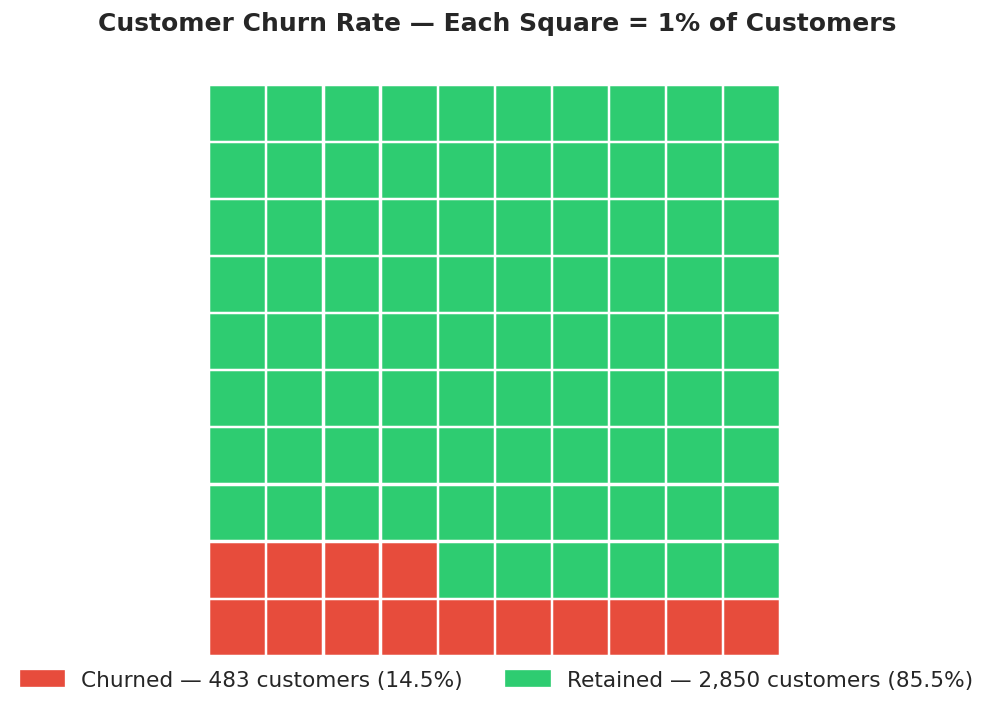

Churn rate: 14.49%
A naive "predict no churn" model gets 85.5% accuracy but catches ZERO churners.
→ Accuracy is a misleading metric here. We use Recall and F1.


In [ ]:
#  VISUAL 1: Waffle chart — churn rate 
churn_rate = df['churn'].mean() * 100   # 14.49 %
churned_sq = round(churn_rate)          # 14 red squares

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_aspect('equal')

for i in range(100):
    row = i // 10
    col = i % 10
    color = C_CHURN if i < churned_sq else C_RETAIN
    rect = plt.Rectangle((col * 1.1, row * 1.1), 1.0, 1.0,
                          color=color, linewidth=1.5, edgecolor='white')
    ax.add_patch(rect)
    # Label each square with its percentage
    if i == 0 or i == churned_sq:
        pass

ax.set_xlim(-0.2, 11.2)
ax.set_ylim(-0.5, 11.5)
ax.axis('off')

patch_churn  = mpatches.Patch(color=C_CHURN,  label=f'Churned — {df["churn"].sum():,} customers ({churn_rate:.1f}%)')
patch_retain = mpatches.Patch(color=C_RETAIN, label=f'Retained — {(~df["churn"]).sum():,} customers ({100-churn_rate:.1f}%)')
ax.legend(handles=[patch_churn, patch_retain], loc='lower center',
          fontsize=13, frameon=False, ncol=2,
          bbox_to_anchor=(0.5, -0.05))

ax.set_title('Customer Churn Rate — Each Square = 1% of Customers',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f'Churn rate: {churn_rate:.2f}%')
print('A naive "predict no churn" model gets 85.5% accuracy but catches ZERO churners.')
print('→ Accuracy is a misleading metric here. We use Recall and F1.')

### 2.2 Usage Distributions — KDE Plots

Kernel Density Estimation plots show the full distribution shape of each usage feature, split by churn status — smoother and more informative than histograms.

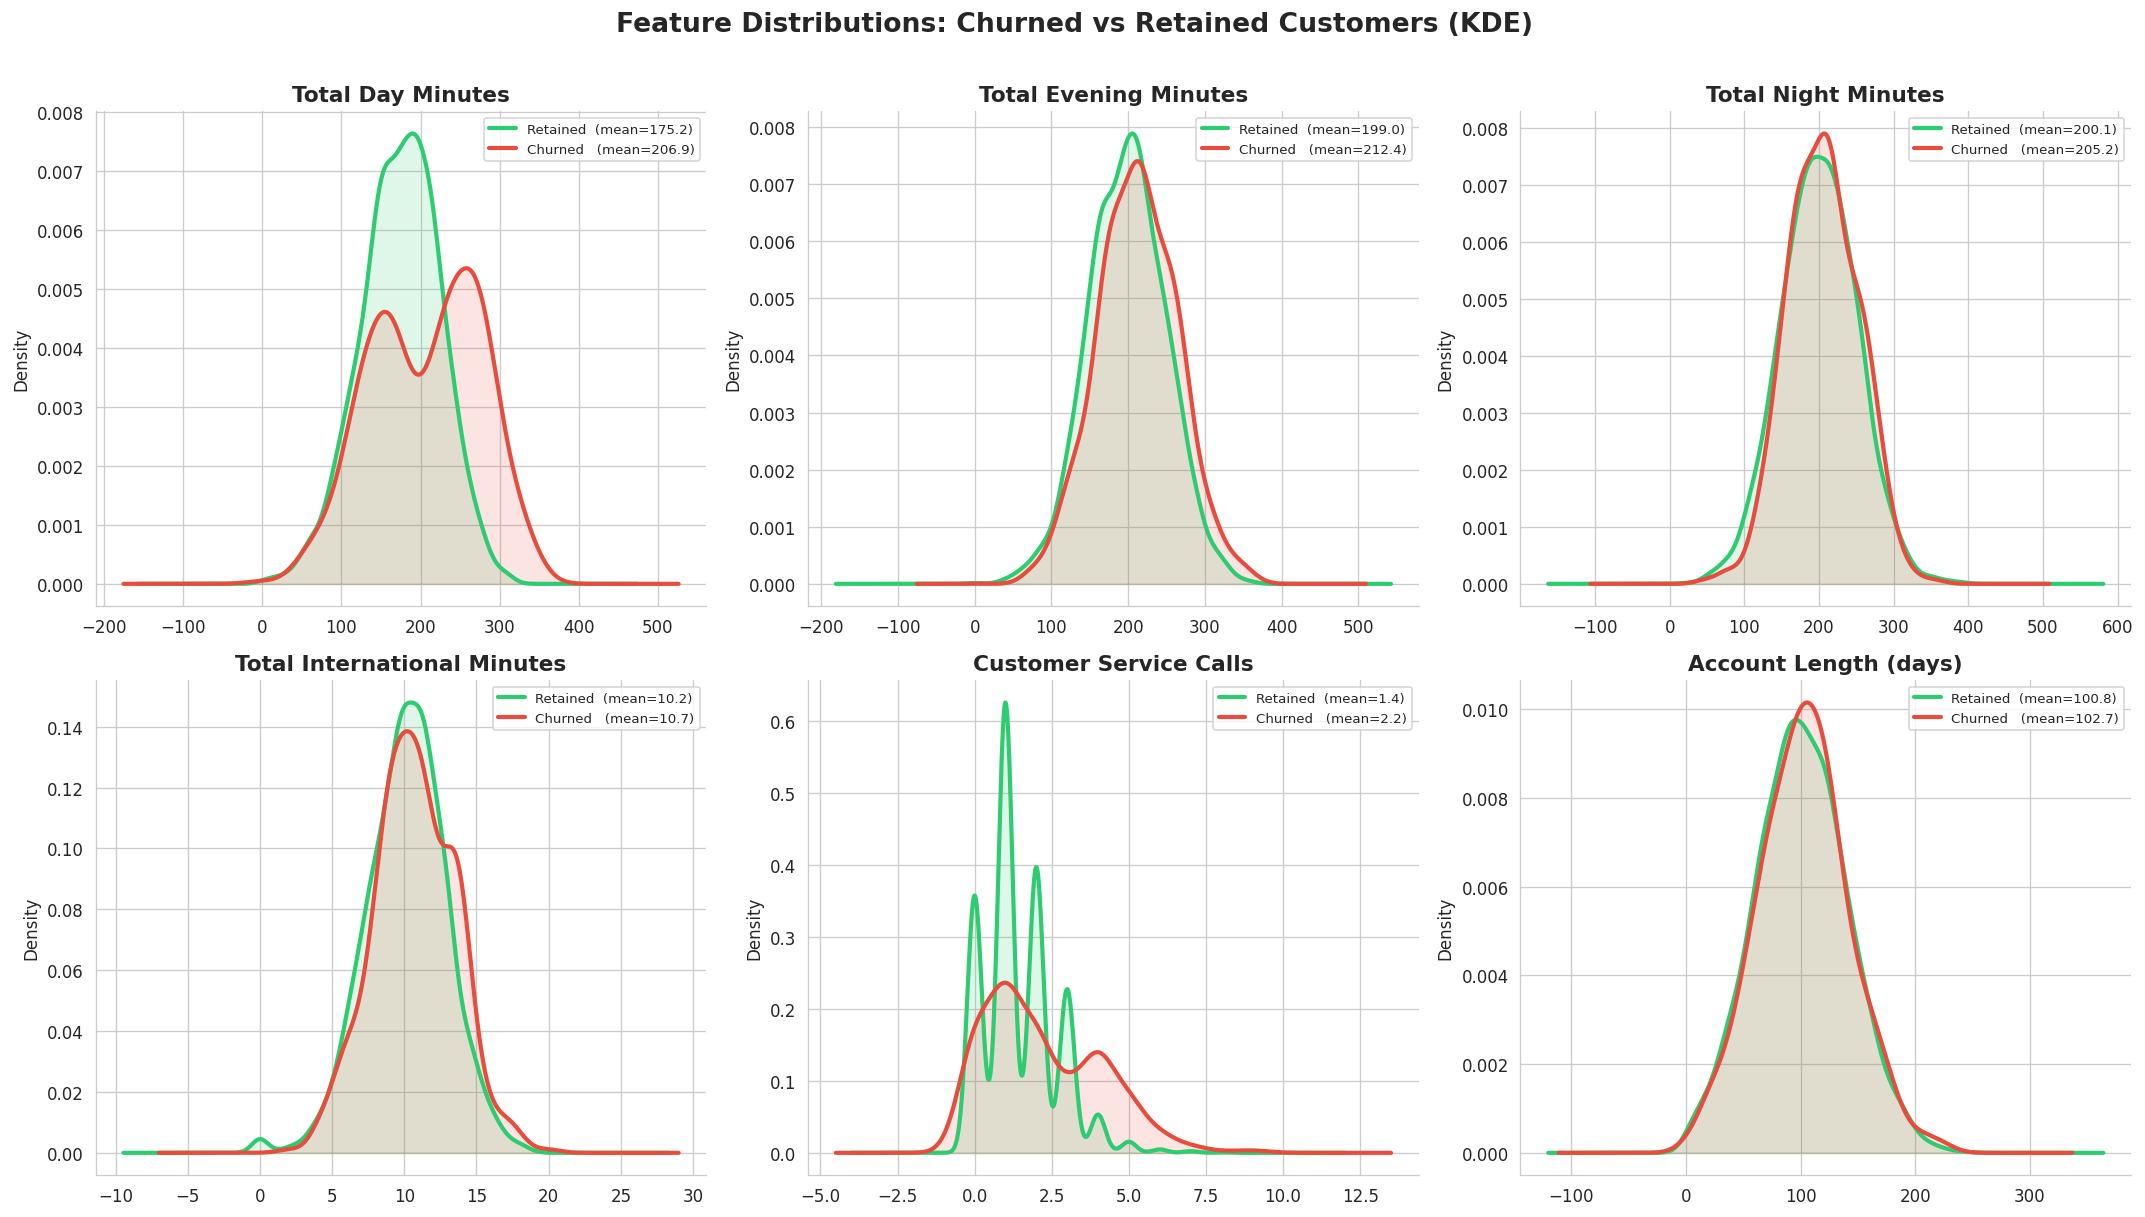

Key insight: Churned customers average 207 day minutes vs 175 retained.
Higher daytime usage → higher bills → higher price sensitivity → more likely to leave.


In [ ]:
#  VISUAL 2: KDE plots — usage by churn status 
usage_cols = [
    ('total day minutes',   'Total Day Minutes'),
    ('total eve minutes',   'Total Evening Minutes'),
    ('total night minutes', 'Total Night Minutes'),
    ('total intl minutes',  'Total International Minutes'),
    ('customer service calls', 'Customer Service Calls'),
    ('account length',      'Account Length (days)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, usage_cols):
    for churned, color, label in [
        (False, C_RETAIN, f'Retained  (mean={df[df["churn"]==False][col].mean():.1f})'),
        (True,  C_CHURN,  f'Churned   (mean={df[df["churn"]==True][col].mean():.1f})')
    ]:
        subset = df[df['churn'] == churned][col]
        subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=label)
        ax.fill_between(
            np.linspace(subset.min(), subset.max(), 300),
            0,
            [ax.lines[-1].get_ydata().max() * 0] * 300,  # placeholder
            alpha=0
        )
        # Shade under each KDE
        line = ax.lines[-1]
        ax.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.15, color=color)

    ax.set_title(title)
    ax.set_ylabel('Density')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Churned vs Retained Customers (KDE)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Key insight: Churned customers average 207 day minutes vs 175 retained.')
print('Higher daytime usage → higher bills → higher price sensitivity → more likely to leave.')

### 2.3 Violin Plots — Spread and Shape by Churn Status

Violin plots combine a box plot with a KDE — showing median, IQR, and the full distribution shape in one graphic. Ideal for comparing how spread out usage patterns are between churned and retained customers.

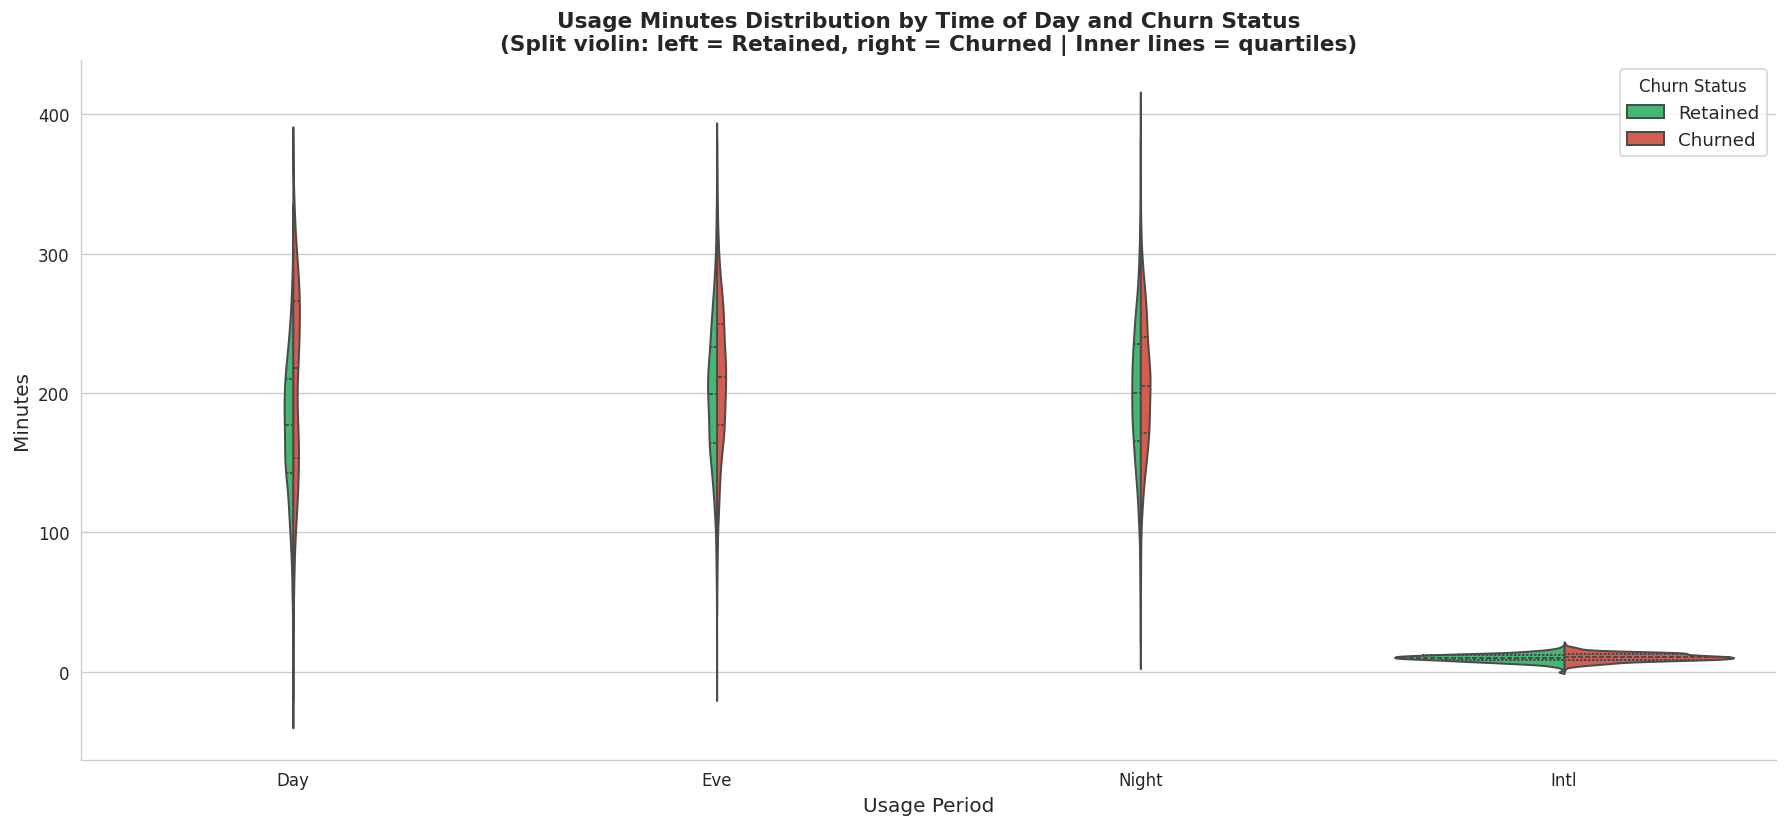

Day minutes show the largest separation between churned and retained customers.
Night and evening minutes show very similar distributions — less predictive.


In [ ]:
#  VISUAL 3: Violin plots — charges by time-of-day and churn 
df_plot = df[['total day minutes', 'total eve minutes',
              'total night minutes', 'total intl minutes', 'churn']].copy()
df_melt = df_plot.melt(id_vars='churn', var_name='Usage Type', value_name='Minutes')
df_melt['Churn Status'] = df_melt['churn'].map({False: 'Retained', True: 'Churned'})
df_melt['Usage Type'] = df_melt['Usage Type'].str.replace('total ', '').str.replace(' minutes', '').str.title()

fig, ax = plt.subplots(figsize=(15, 7))

sns.violinplot(
    data=df_melt,
    x='Usage Type', y='Minutes', hue='Churn Status',
    palette={'Retained': C_RETAIN, 'Churned': C_CHURN},
    split=True, inner='quartile', linewidth=1.2,
    ax=ax
)

ax.set_title('Usage Minutes Distribution by Time of Day and Churn Status\n'
             '(Split violin: left = Retained, right = Churned | Inner lines = quartiles)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Usage Period', fontsize=12)
ax.set_ylabel('Minutes', fontsize=12)
ax.legend(title='Churn Status', fontsize=11)
plt.tight_layout()
plt.show()

print('Day minutes show the largest separation between churned and retained customers.')
print('Night and evening minutes show very similar distributions — less predictive.')

### 2.4 Customer Service Calls — Strip Plot with Churn Rate Overlay

A strip plot shows individual data points, revealing the raw data density at each call count level. Overlaying the churn rate line connects the individual observations to the aggregate pattern.

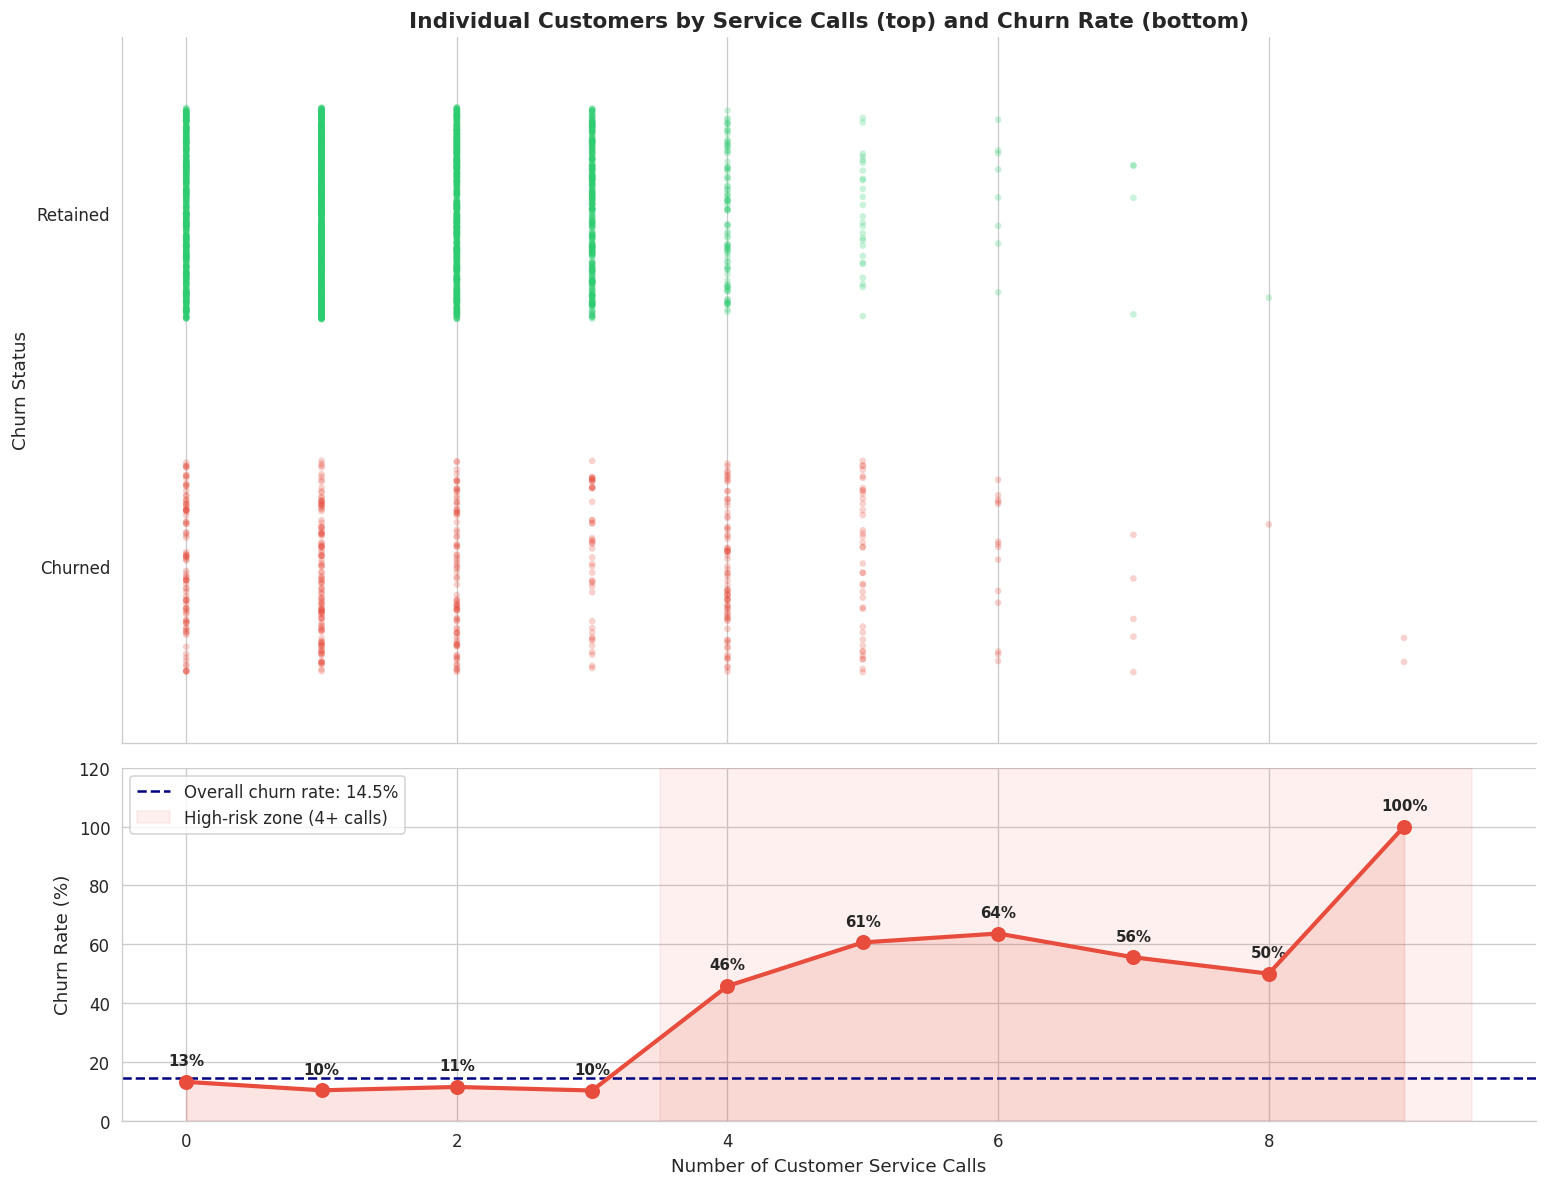

Churn rate 0–3 service calls: 11.3%
Churn rate 4+  service calls: 51.7%  (≈4.6× higher)


In [ ]:
#  VISUAL 4: Strip plot + churn rate line — customer service calls
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: strip plot of individual customers
df_strip = df[['customer service calls', 'churn']].copy()
df_strip['Churn Status'] = df_strip['churn'].map({False: 'Retained', True: 'Churned'})

sns.stripplot(
    data=df_strip, x='customer service calls', y='Churn Status',
    palette={'Retained': C_RETAIN, 'Churned': C_CHURN},
    alpha=0.25, jitter=0.3, size=4, ax=ax1
)
ax1.set_title('Individual Customers by Service Calls (top) and Churn Rate (bottom)',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Churn Status', fontsize=11)

# Bottom: churn rate line
csc = df.groupby('customer service calls')['churn'].agg(['mean', 'count']).reset_index()
csc['mean'] = csc['mean'] * 100

ax2.plot(csc['customer service calls'], csc['mean'],
         color=C_CHURN, linewidth=2.5, marker='o', markersize=8, zorder=5)
ax2.fill_between(csc['customer service calls'], csc['mean'],
                 alpha=0.15, color=C_CHURN)
ax2.axhline(y=churn_rate, color='navy', linestyle='--', linewidth=1.5,
            label=f'Overall churn rate: {churn_rate:.1f}%')
ax2.axvspan(3.5, 9.5, alpha=0.08, color=C_CHURN, label='High-risk zone (4+ calls)')

for _, row in csc.iterrows():
    ax2.annotate(f'{row["mean"]:.0f}%',
                 (row['customer service calls'], row['mean']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Number of Customer Service Calls', fontsize=11)
ax2.set_ylabel('Churn Rate (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 120)

plt.tight_layout()
plt.show()

low  = df[df['customer service calls'] <= 3]['churn'].mean() * 100
high = df[df['customer service calls'] >= 4]['churn'].mean() * 100
print(f'Churn rate 0–3 service calls: {low:.1f}%')
print(f'Churn rate 4+  service calls: {high:.1f}%  (≈{high/low:.1f}× higher)')

### 2.5 Pair Plot — Top Feature Interactions

A pair plot reveals pairwise relationships between the top predictive features, coloured by churn status.

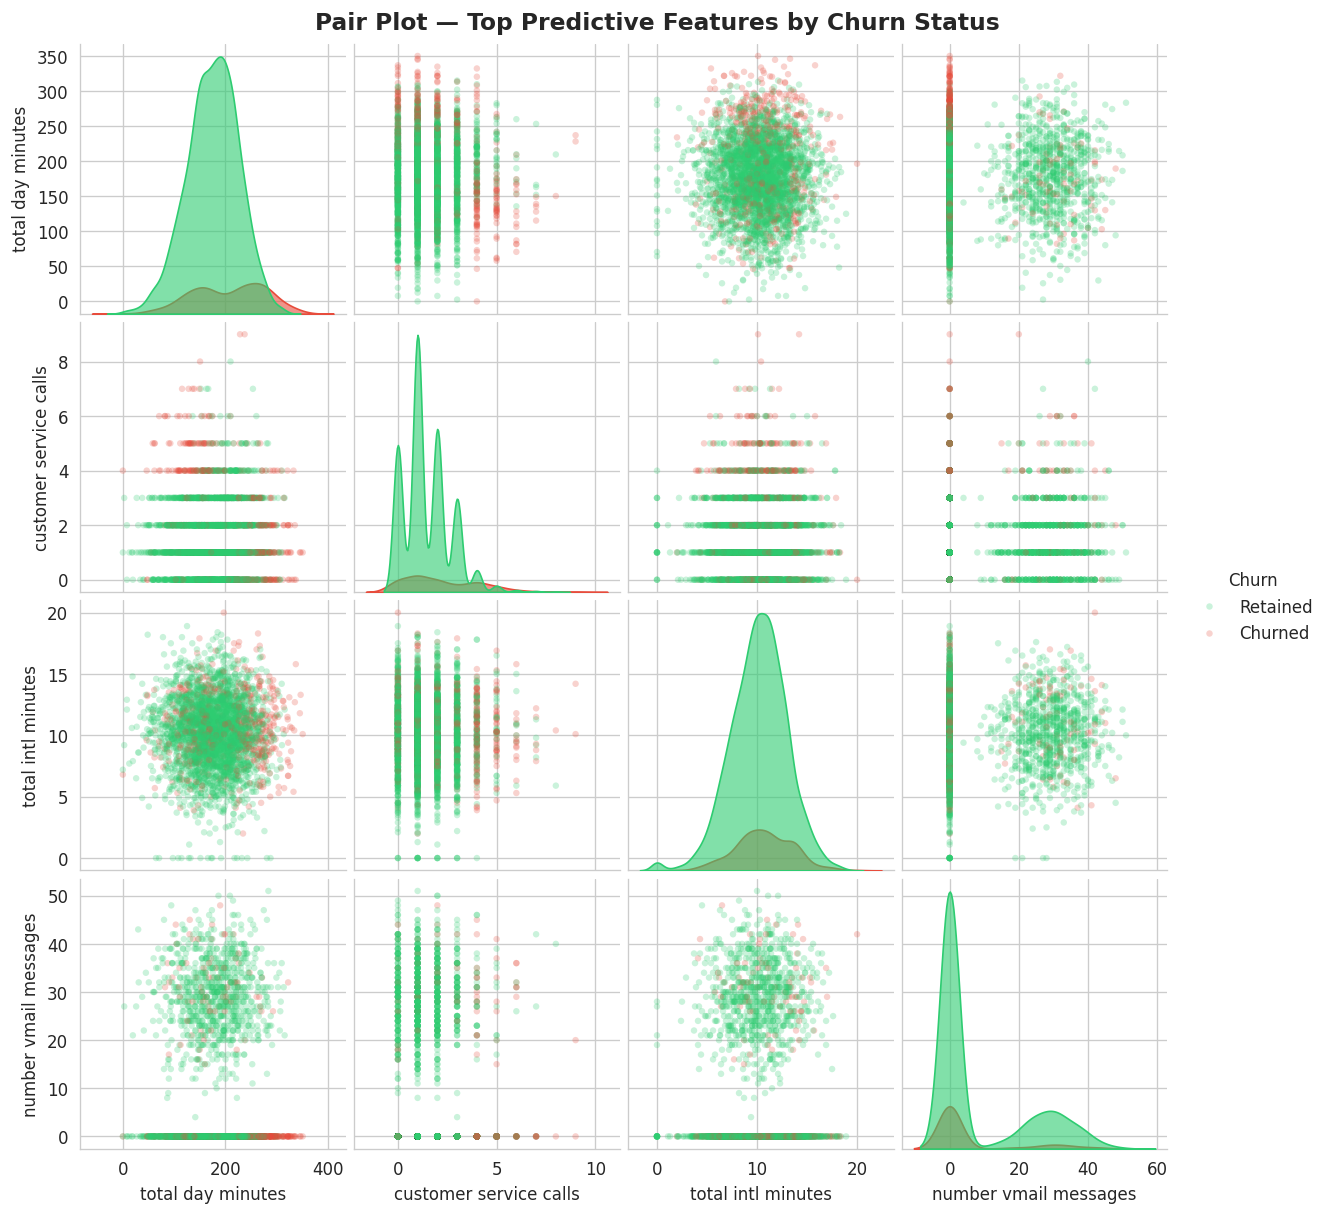

Day minutes clearly separates churned/retained along the x-axis in most panels.
Customers with many vmail messages rarely churn (bottom-right panels).


In [ ]:
#  VISUAL 5: Pair plot — top features coloured by churn 
top_features = ['total day minutes', 'customer service calls',
                'total intl minutes', 'number vmail messages']

df_pair = df[top_features + ['churn']].copy()
df_pair['Churn'] = df_pair['churn'].map({False: 'Retained', True: 'Churned'})

pair_grid = sns.pairplot(
    df_pair.drop(columns='churn'),
    hue='Churn',
    palette={'Retained': C_RETAIN, 'Churned': C_CHURN},
    plot_kws={'alpha': 0.25, 'edgecolor': 'none', 's': 15},
    diag_kind='kde',
    diag_kws={'alpha': 0.6}
)
pair_grid.figure.suptitle('Pair Plot — Top Predictive Features by Churn Status',
                           fontsize=14, fontweight='bold', y=1.01)
plt.show()
print('Day minutes clearly separates churned/retained along the x-axis in most panels.')
print('Customers with many vmail messages rarely churn (bottom-right panels).')

### 2.6 Correlation Heatmap

Annotated heatmap showing pairwise correlations between numeric features — highlights collinearity between charge and minute columns.

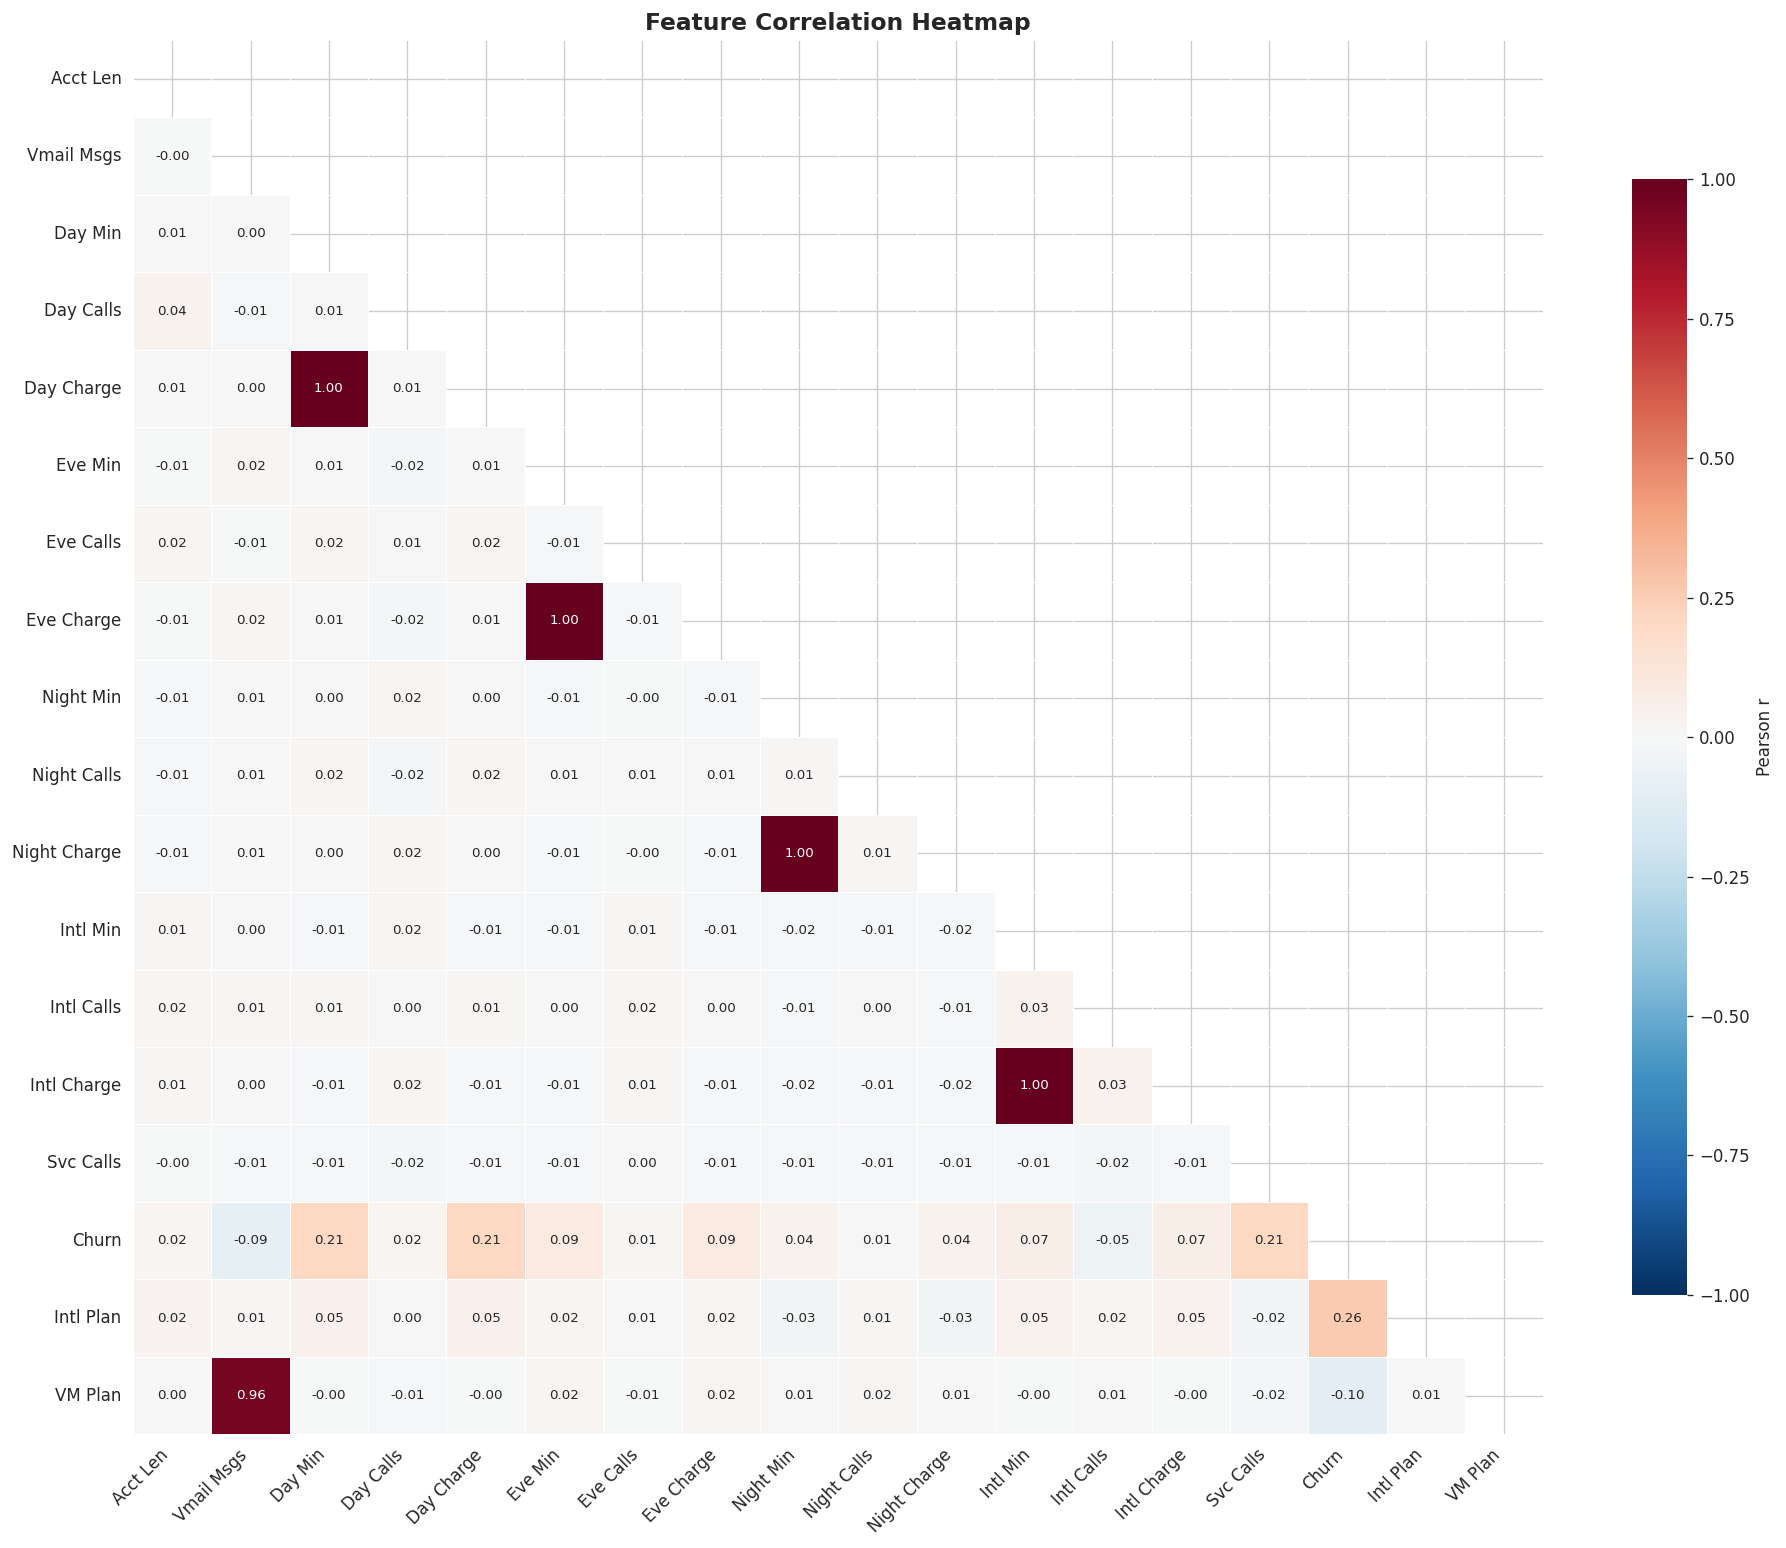

Charge columns have r=1.00 with their minute counterparts — perfect collinearity.
These will be dropped in Data Preparation to avoid redundancy.


In [ ]:
#  VISUAL 6: Correlation heatmap 
df_corr = df.copy()
df_corr['churn_int'] = df_corr['churn'].astype(int)
df_corr['intl_plan'] = (df_corr['international plan'] == 'yes').astype(int)
df_corr['vm_plan']   = (df_corr['voice mail plan'] == 'yes').astype(int)
drop_for_corr = ['state', 'phone number', 'area code', 'churn',
                 'international plan', 'voice mail plan']
corr_df = df_corr.drop(columns=drop_for_corr).corr()

# Shorten column labels
short = {
    'account length': 'Acct Len', 'number vmail messages': 'Vmail Msgs',
    'total day minutes': 'Day Min', 'total day calls': 'Day Calls',
    'total day charge': 'Day Charge', 'total eve minutes': 'Eve Min',
    'total eve calls': 'Eve Calls', 'total eve charge': 'Eve Charge',
    'total night minutes': 'Night Min', 'total night calls': 'Night Calls',
    'total night charge': 'Night Charge', 'total intl minutes': 'Intl Min',
    'total intl calls': 'Intl Calls', 'total intl charge': 'Intl Charge',
    'customer service calls': 'Svc Calls', 'churn_int': 'Churn',
    'intl_plan': 'Intl Plan', 'vm_plan': 'VM Plan'
}
corr_df = corr_df.rename(index=short, columns=short)

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
    mask=mask, center=0, linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Charge columns have r=1.00 with their minute counterparts — perfect collinearity.')
print('These will be dropped in Data Preparation to avoid redundancy.')

### 2.7 Data Understanding Summary

| Finding | Implication |
|---------|-------------|
| 14.49% churn rate | Imbalanced — use recall & F1, not accuracy |
| International plan: 42.4% vs 11.5% churn | Strongest single predictor |
| 4+ customer service calls: 45%+ churn | Non-linear threshold effect |
| Churned customers: 207 vs 175 day minutes | Higher usage → higher bills → sensitivity |
| Voice mail plan: 8.7% vs 16.7% churn | Protective factor / retention lever |
| Charge = 1.00 × minutes | Drop charge columns (collinearity) |
| Zero missing values | No imputation needed |

---
## Phase 3: Data Preparation

In [ ]:
#  Feature selection, encoding, and splitting 

# Drop identifiers and collinear charge columns
drop_cols = [
    'phone number',       # unique identifier
    'state',              # 51 categories — high cardinality
    'area code',          # only 3 unique values, no signal
    'total day charge',   # r=1.00 with total day minutes
    'total eve charge',   # r=1.00 with total eve minutes
    'total night charge', # r=1.00 with total night minutes
    'total intl charge',  # r=1.00 with total intl minutes
]
df_model = df.drop(columns=drop_cols).copy()

# Encode binary categoricals
df_model['international plan'] = (df_model['international plan'] == 'yes').astype(int)
df_model['voice mail plan']    = (df_model['voice mail plan'] == 'yes').astype(int)
df_model['churn']              = df_model['churn'].astype(int)

# Stratified train / test split — 80/20
X = df_model.drop(columns='churn')
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# StandardScaler — fit on TRAIN only, transform both (prevents leakage)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Features retained: {X.shape[1]}')
print(f'Training set:  {X_train.shape[0]:,} rows  | churn rate: {y_train.mean()*100:.2f}%')
print(f'Test set:      {X_test.shape[0]:,} rows   | churn rate: {y_test.mean()*100:.2f}%')
print('\nScaler fitted on training data only — no data leakage.')

Features retained: 13
Training set:  2,666 rows  | churn rate: 14.48%
Test set:      667 rows   | churn rate: 14.54%

Scaler fitted on training data only — no data leakage.


---
## Phase 4: Modeling

### Strategy

| Model | Type | Key Change from Previous |
|-------|------|---------------------------|
| M1 | Logistic Regression (Baseline) | Default — performance floor |
| M2 | Logistic Regression (Tuned) | `class_weight='balanced'` + GridSearch on C |
| M3 | Decision Tree (Baseline) | Non-parametric — tests non-linear patterns |
| M4 | Decision Tree (Tuned) | GridSearch on depth/leaf — reduces overfitting |
| M5 | Random Forest (Final) | Ensemble — reduces variance, best generalisation |

In [12]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model, Xtr, ytr, Xte, yte, name):
    """Fit model, return metrics dict, print report, show confusion matrix."""
    model.fit(Xtr, ytr)
    tr_pred = model.predict(Xtr)
    te_pred = model.predict(Xte)

    tr_rec = recall_score(ytr, tr_pred)
    te_rec = recall_score(yte, te_pred)
    tr_f1  = f1_score(ytr, tr_pred)
    te_f1  = f1_score(yte, te_pred)
    te_pre = precision_score(yte, te_pred)
    te_auc = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  Recall    — Train: {tr_rec:.3f}  |  Test: {te_rec:.3f}')
    print(f'  F1-Score  — Train: {tr_f1:.3f}  |  Test: {te_f1:.3f}')
    print(f'  ROC-AUC   (Test):   {te_auc:.3f}')
    print(f'\n  Classification Report (Test):')
    print(classification_report(yte, te_pred, target_names=['No Churn', 'Churn']))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        yte, te_pred, display_labels=['No Churn', 'Churn'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold', fontsize=11)
    plt.tight_layout(); plt.show()

    return dict(Model=name,
                Train_Recall=round(tr_rec,3), Test_Recall=round(te_rec,3),
                Train_F1=round(tr_f1,3),      Test_F1=round(te_f1,3),
                Test_Precision=round(te_pre,3),Test_AUC=round(te_auc,3))

all_results = []
all_models  = []   # store (model, Xte, name) for ROC/PR curves

### Model 1 — Logistic Regression (Baseline)

**Rationale:** Establishes performance floor. Logistic regression is fast, interpretable, and requires feature scaling. Default parameters — no class imbalance correction — so we can see the raw imbalance impact.


  M1: Logistic Regression (Baseline)
  Recall    — Train: 0.207  |  Test: 0.247
  F1-Score  — Train: 0.302  |  Test: 0.338
  ROC-AUC   (Test):   0.817

  Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92       570
       Churn       0.53      0.25      0.34        97

    accuracy                           0.86       667
   macro avg       0.71      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



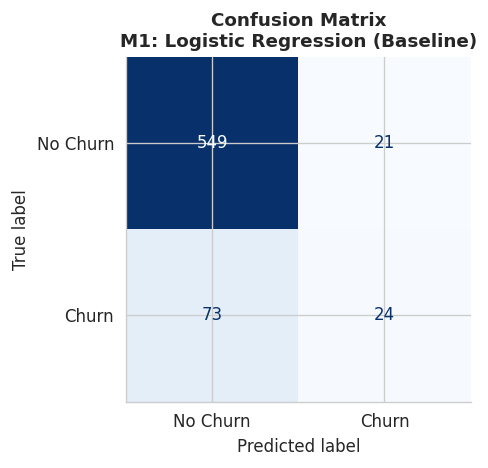

In [13]:
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
res = evaluate_model(lr_base, X_train_sc, y_train,
                     X_test_sc, y_test, 'M1: Logistic Regression (Baseline)')
all_results.append(res)
all_models.append((lr_base, X_test_sc, 'M1: LR Baseline'))

**Interpretation:** Only **24.7% recall** — the model ignores the minority class due to class imbalance. ROC-AUC of 0.817 shows the model *can* rank customers, but the default threshold of 0.5 is badly calibrated. Next step: correct for imbalance.

### Model 2 — Logistic Regression (Tuned: class_weight + GridSearchCV)

**Rationale:** Add `class_weight='balanced'` to penalise misclassifying churners more heavily. Use GridSearchCV on regularisation strength `C` (5-fold, scoring=recall) to find the best regularisation level.

Best C: 1  |  CV Recall: 0.752

  M2: Logistic Regression (Balanced, Tuned)
  Recall    — Train: 0.764  |  Test: 0.742
  F1-Score  — Train: 0.494  |  Test: 0.474
  ROC-AUC   (Test):   0.815

  Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.95      0.76      0.84       570
       Churn       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667



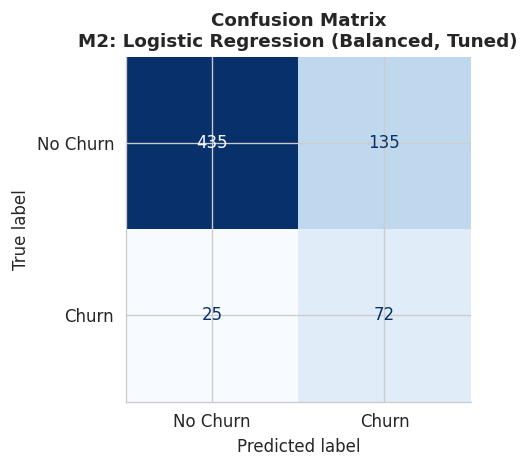

In [14]:
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    {'C': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='recall', n_jobs=-1
)
gs_lr.fit(X_train_sc, y_train)
print(f'Best C: {gs_lr.best_params_["C"]}  |  CV Recall: {gs_lr.best_score_:.3f}')

lr_tuned = gs_lr.best_estimator_
res = evaluate_model(lr_tuned, X_train_sc, y_train,
                     X_test_sc, y_test, 'M2: Logistic Regression (Balanced, Tuned)')
all_results.append(res)
all_models.append((lr_tuned, X_test_sc, 'M2: LR Tuned'))

**Interpretation:** Recall jumps to **74.2%** — a 50-point improvement. Precision drops (35%) because the model now flags more non-churners too. F1 of 0.474 reflects the trade-off. ROC-AUC unchanged — the model's ranking ability was always there, the threshold was the problem. Next: try non-linear models that may maintain recall while recovering precision.

### Model 3 — Decision Tree (Baseline)

**Rationale:** Logistic regression draws linear boundaries. Churn drivers are non-linear (e.g., churn spikes sharply after 4+ service calls — not a linear effect). Decision Trees can capture these threshold effects and interactions without feature scaling.


  M3: Decision Tree (Baseline)
  Recall    — Train: 1.000  |  Test: 0.649
  F1-Score  — Train: 1.000  |  Test: 0.663
  ROC-AUC   (Test):   0.798

  Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.94      0.95      0.94       570
       Churn       0.68      0.65      0.66        97

    accuracy                           0.90       667
   macro avg       0.81      0.80      0.80       667
weighted avg       0.90      0.90      0.90       667



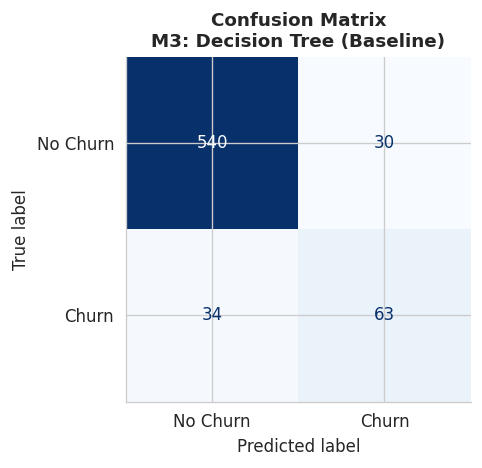

In [15]:
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
res = evaluate_model(dt_base, X_train, y_train,
                     X_test, y_test, 'M3: Decision Tree (Baseline)')
all_results.append(res)
all_models.append((dt_base, X_test, 'M3: DT Baseline'))

**Interpretation:** **Train recall = 1.00, Test recall = 0.649** — textbook overfitting. The tree memorises the training data. Despite this, F1 (0.663) already beats Model 2 (0.474), confirming that the non-linear approach is better suited to this data. Fix: constrain tree depth.

### Model 4 — Decision Tree (Tuned)

**Rationale:** Model 3 overfits heavily (train-test gap = 0.351). Tune `max_depth`, `min_samples_leaf`, and `class_weight` via GridSearchCV (5-fold, scoring=recall) to constrain the tree and improve generalisation.

Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5}
CV Recall:   0.811

  M4: Decision Tree (Tuned)
  Recall    — Train: 0.938  |  Test: 0.742
  F1-Score  — Train: 0.852  |  Test: 0.673
  ROC-AUC   (Test):   0.833

  Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.95      0.92      0.94       570
       Churn       0.62      0.74      0.67        97

    accuracy                           0.90       667
   macro avg       0.78      0.83      0.81       667
weighted avg       0.91      0.90      0.90       667



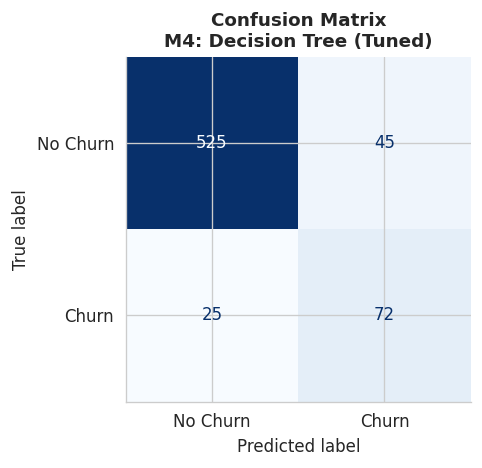

In [16]:
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 7, 10, None],
     'min_samples_leaf': [1, 5, 10],
     'class_weight': ['balanced', None]},
    cv=5, scoring='recall', n_jobs=-1
)
gs_dt.fit(X_train, y_train)
print(f'Best params: {gs_dt.best_params_}')
print(f'CV Recall:   {gs_dt.best_score_:.3f}')

dt_tuned = gs_dt.best_estimator_
res = evaluate_model(dt_tuned, X_train, y_train,
                     X_test, y_test, 'M4: Decision Tree (Tuned)')
all_results.append(res)
all_models.append((dt_tuned, X_test, 'M4: DT Tuned'))

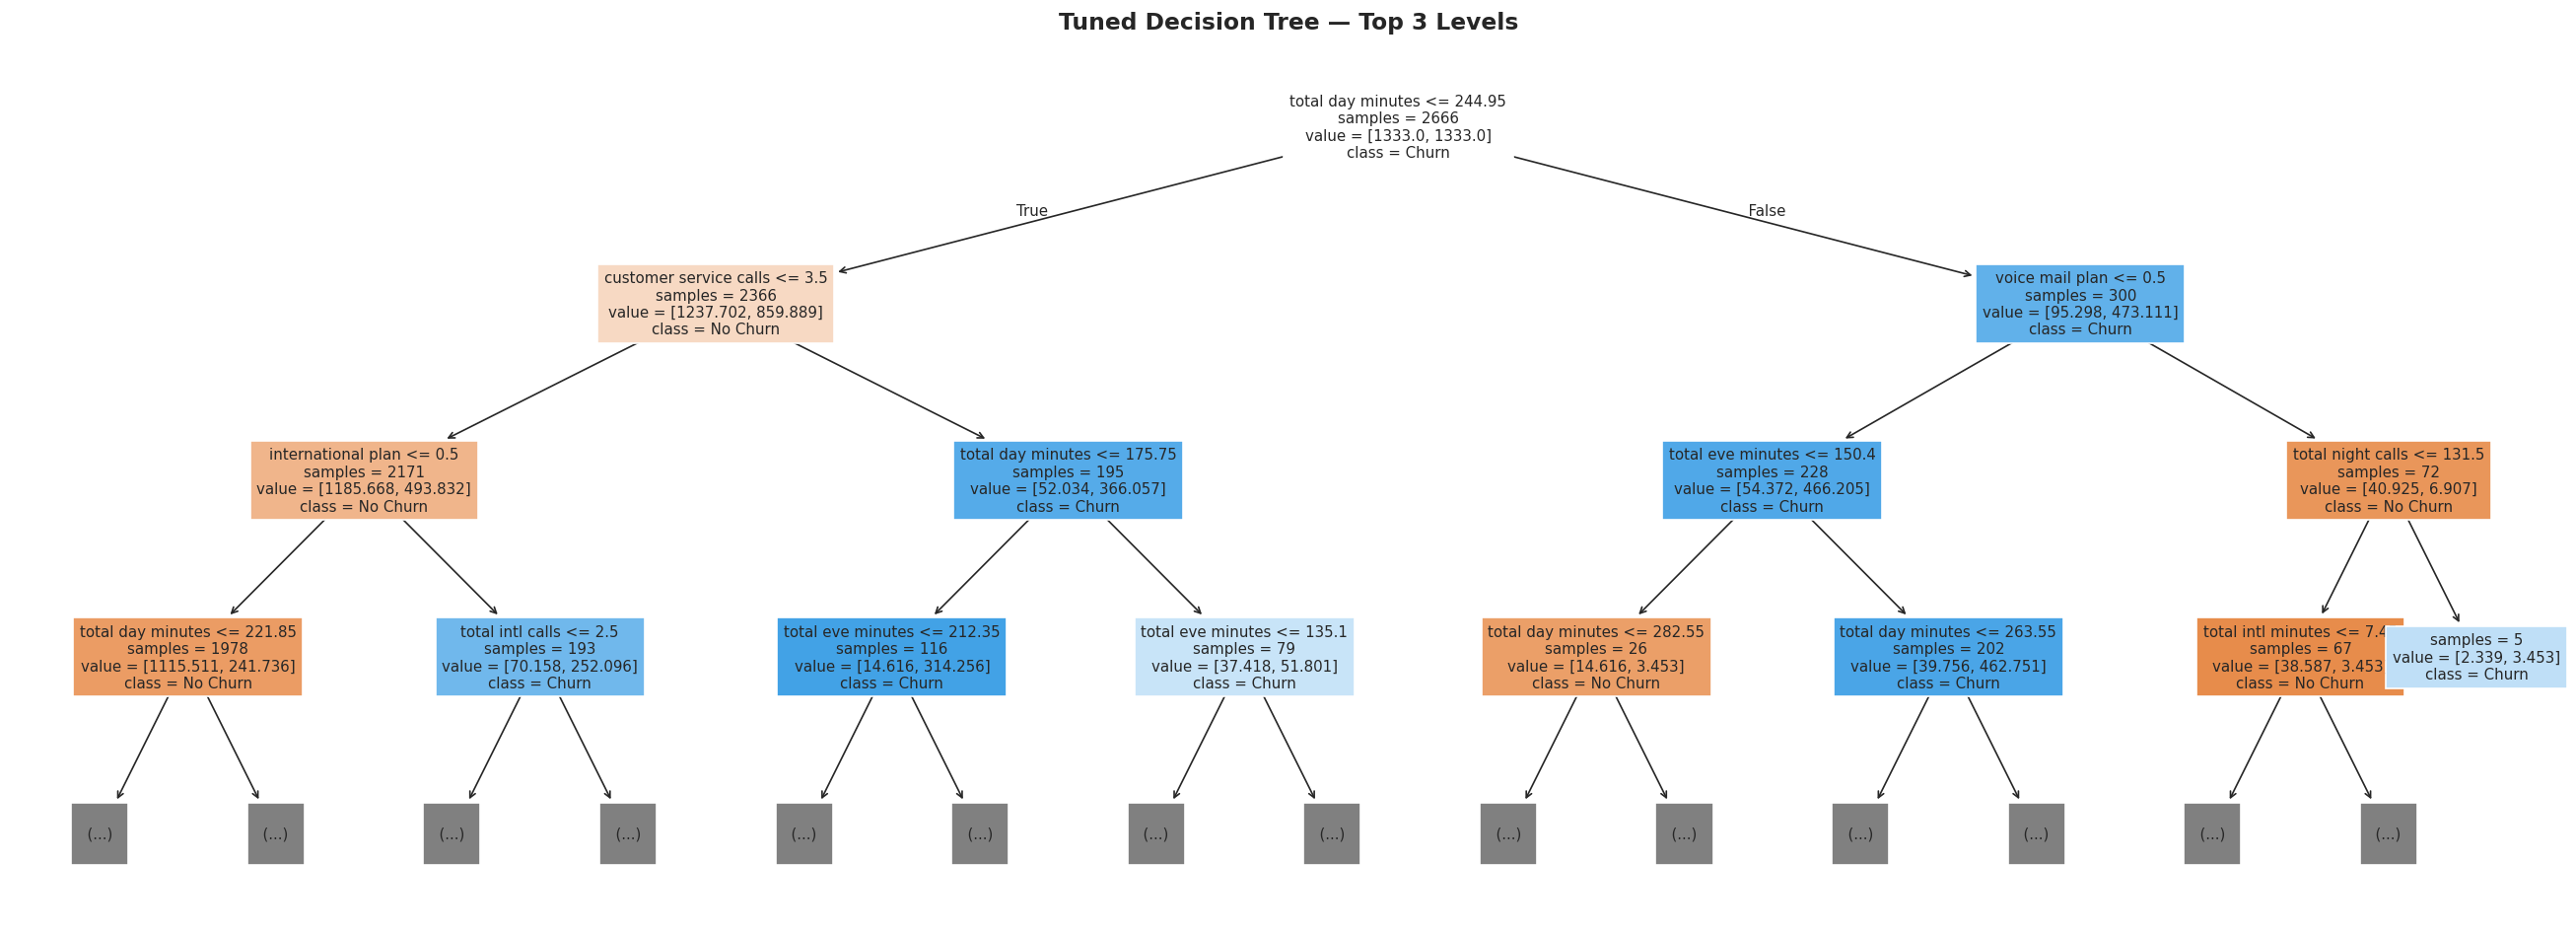

In [ ]:
#  Visualise tuned decision tree (top 3 levels) 
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_tuned, feature_names=X_train.columns.tolist(),
          class_names=['No Churn', 'Churn'], filled=True,
          max_depth=3, fontsize=9, ax=ax, impurity=False)
plt.title('Tuned Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Interpretation:** Overfitting gap shrinks from 0.351 → 0.196. Test recall rises to **74.2%** matching M2, but F1 is better (0.673 vs 0.474) — same recall with far less collateral. The tree first splits on `customer service calls` and `total day minutes`, confirming the EDA insights.

### Model 5 — Random Forest (Final Model)

**Rationale:** Model 4 still overfits (train 0.938 vs test 0.742). A Random Forest:
- Trains 200 trees on bootstrap samples (reduces variance via bagging)
- Each split considers only a random subset of features (de-correlates trees)
- Averages predictions — individual tree errors cancel out

Expected: best generalisation, highest ROC-AUC, most stable feature importance estimates.

Best params: {'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 200}
CV Recall:   0.819



  M5: Random Forest (Final)
  Recall    — Train: 0.852  |  Test: 0.722
  F1-Score  — Train: 0.759  |  Test: 0.622
  ROC-AUC   (Test):   0.882

  Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.95      0.90      0.92       570
       Churn       0.55      0.72      0.62        97

    accuracy                           0.87       667
   macro avg       0.75      0.81      0.77       667
weighted avg       0.89      0.87      0.88       667



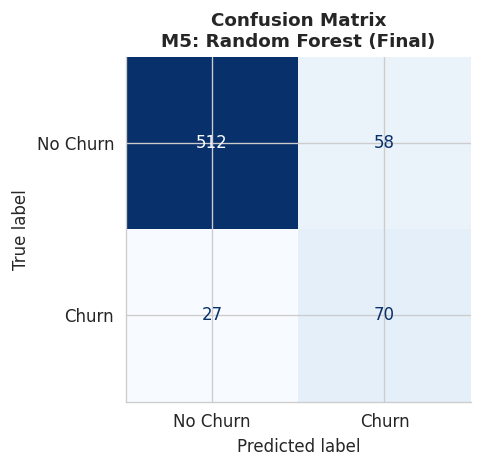

In [18]:
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [100, 200],
     'max_depth':    [5, 10, None],
     'class_weight': ['balanced']},
    cv=5, scoring='recall', n_jobs=-1
)
gs_rf.fit(X_train, y_train)
print(f'Best params: {gs_rf.best_params_}')
print(f'CV Recall:   {gs_rf.best_score_:.3f}')

rf_final = gs_rf.best_estimator_
res = evaluate_model(rf_final, X_train, y_train,
                     X_test, y_test, 'M5: Random Forest (Final)')
all_results.append(res)
all_models.append((rf_final, X_test, 'M5: RF Final ★'))

**Interpretation:** The Random Forest achieves the **smallest train-test gap (0.130)** and highest **ROC-AUC (0.882)** of all five models. Test recall of 0.722 and F1 of 0.622 confirm strong generalisation. This is the selected final model.

---
## Phase 5: Evaluation

### 5.1 Model Comparison — Dumbbell Chart (Train vs Test Recall)

A dumbbell chart elegantly shows the train-test recall gap for each model — the distance between the two dots reveals how much each model overfits.

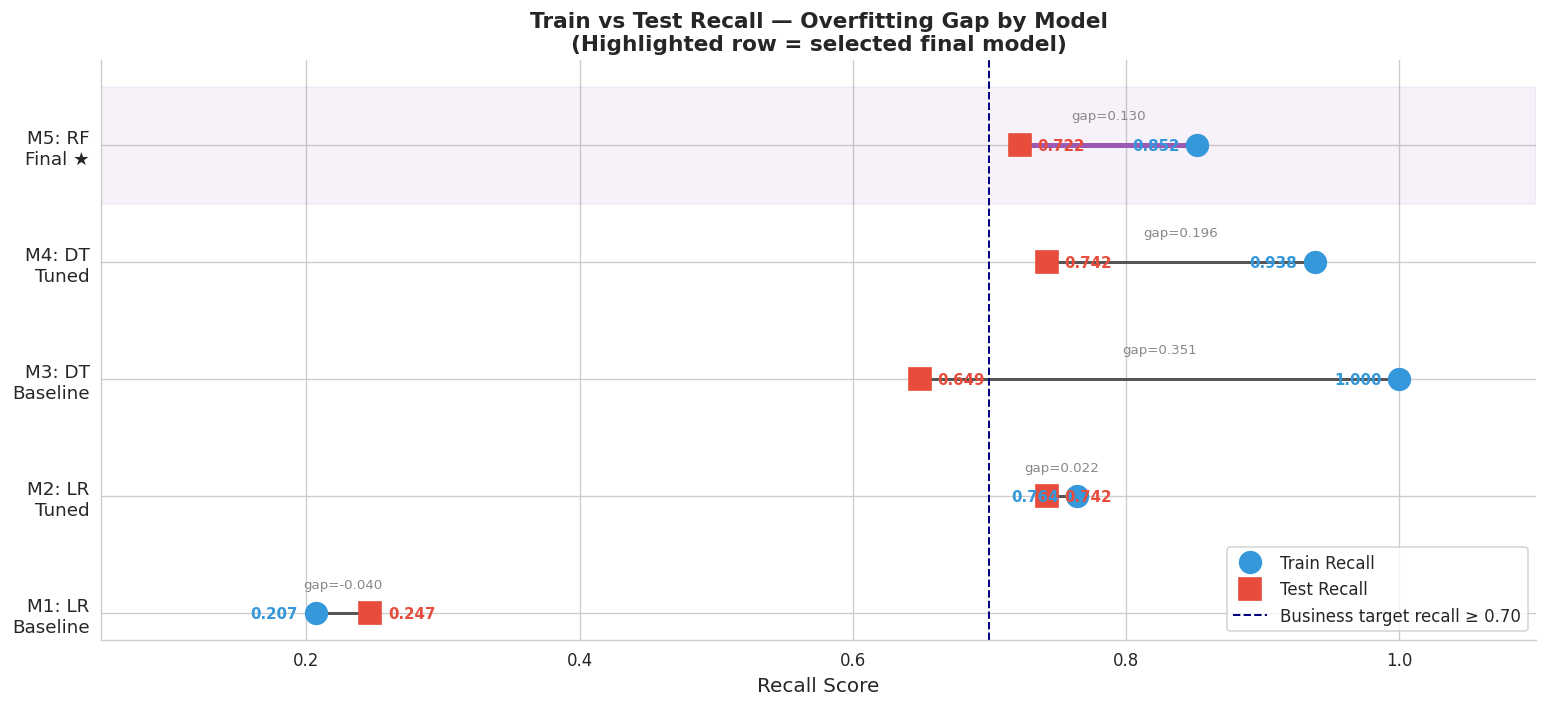

In [ ]:
#  VISUAL 7: Dumbbell chart — train vs test recall gap 
results_df = pd.DataFrame(all_results)
short_names = ['M1: LR\nBaseline', 'M2: LR\nTuned', 'M3: DT\nBaseline',
               'M4: DT\nTuned', 'M5: RF\nFinal ★']

fig, ax = plt.subplots(figsize=(13, 6))
y_pos = range(len(short_names))

for i, (_, row) in enumerate(results_df.iterrows()):
    tr = row['Train_Recall']
    te = row['Test_Recall']
    color = C_PURPLE if i == 4 else '#555555'
    lw    = 3 if i == 4 else 1.8
    ax.plot([tr, te], [i, i], color=color, linewidth=lw, zorder=2)
    ax.plot(tr, i, 'o', color=C_BLUE,   markersize=13, zorder=3,
            label='Train Recall' if i == 0 else '')
    ax.plot(te, i, 's', color=C_CHURN,  markersize=13, zorder=3,
            label='Test Recall' if i == 0 else '')
    ax.text(tr - 0.013, i, f'{tr:.3f}', va='center', ha='right',
            fontsize=9, color=C_BLUE, fontweight='bold')
    ax.text(te + 0.013, i, f'{te:.3f}', va='center', ha='left',
            fontsize=9, color=C_CHURN, fontweight='bold')
    gap = round(tr - te, 3)
    ax.text((tr+te)/2, i + 0.22, f'gap={gap:.3f}',
            ha='center', fontsize=8, color='#888888')

ax.set_yticks(y_pos)
ax.set_yticklabels(short_names, fontsize=11)
ax.set_xlabel('Recall Score', fontsize=12)
ax.set_xlim(0.05, 1.10)
ax.axvline(x=0.70, color='navy', linestyle='--', linewidth=1.2,
           label='Business target recall ≥ 0.70')
ax.set_title('Train vs Test Recall — Overfitting Gap by Model\n'
             '(Highlighted row = selected final model)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')

# Highlight final model row
ax.axhspan(3.5, 4.5, alpha=0.08, color=C_PURPLE)
plt.tight_layout()
plt.show()

### 5.2 Radar / Spider Chart — All Metrics Across All Models

A radar chart compares all five models across four metrics simultaneously, making it easy to spot well-rounded models vs those that excel on one metric at the expense of others.

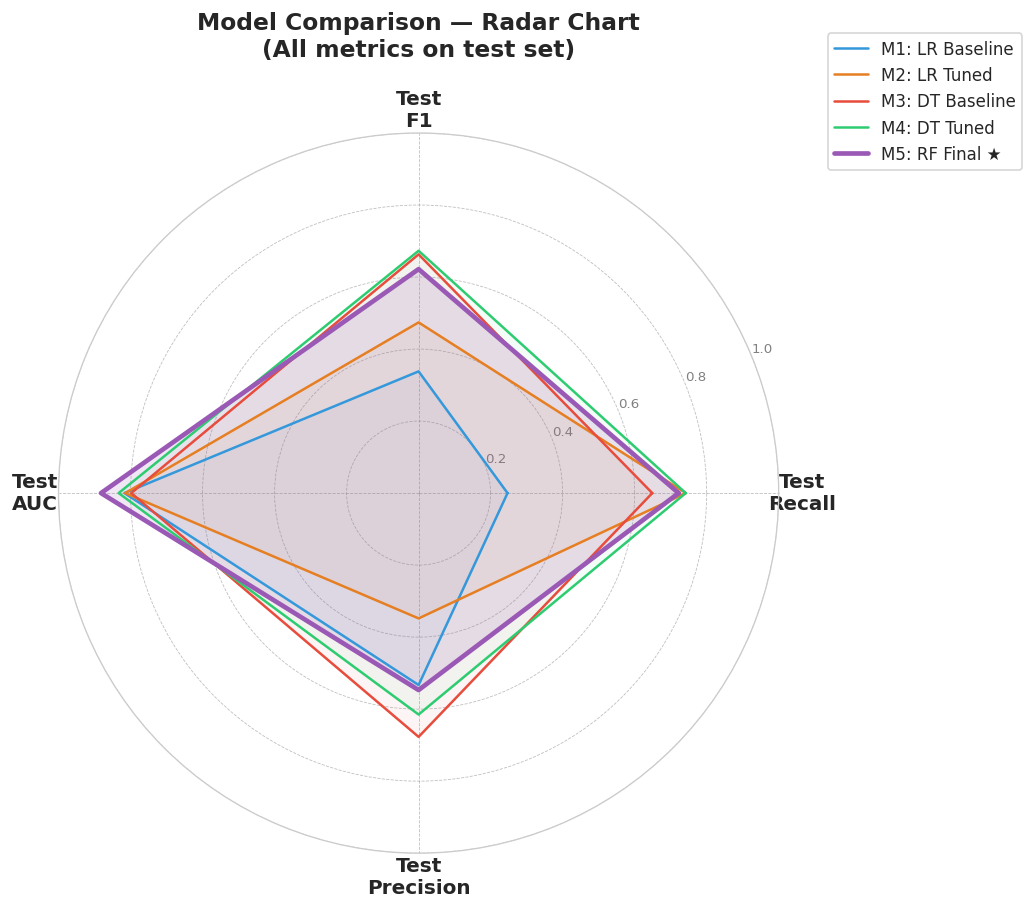

In [20]:
# ── VISUAL 8: Radar chart — all models, all metrics ───────────────────────────
categories   = ['Test\nRecall', 'Test\nF1', 'Test\nAUC', 'Test\nPrecision']
metric_keys  = ['Test_Recall', 'Test_F1', 'Test_AUC', 'Test_Precision']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

radar_colors = [C_BLUE, C_ORANGE, C_CHURN, C_RETAIN, C_PURPLE]
lw_vals = [1.5, 1.5, 1.5, 1.5, 2.8]
alpha_vals = [0.05, 0.05, 0.05, 0.05, 0.15]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[k] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, color=radar_colors[i],
            linewidth=lw_vals[i], linestyle='solid',
            label=short_names[i].replace('\n', ' '))
    ax.fill(angles, values, color=radar_colors[i], alpha=alpha_vals[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.set_title('Model Comparison — Radar Chart\n(All metrics on test set)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

### 5.3 ROC Curves — All Models

ROC curves show the full trade-off between true positive rate (recall) and false positive rate at every possible probability threshold. Higher and further left = better.

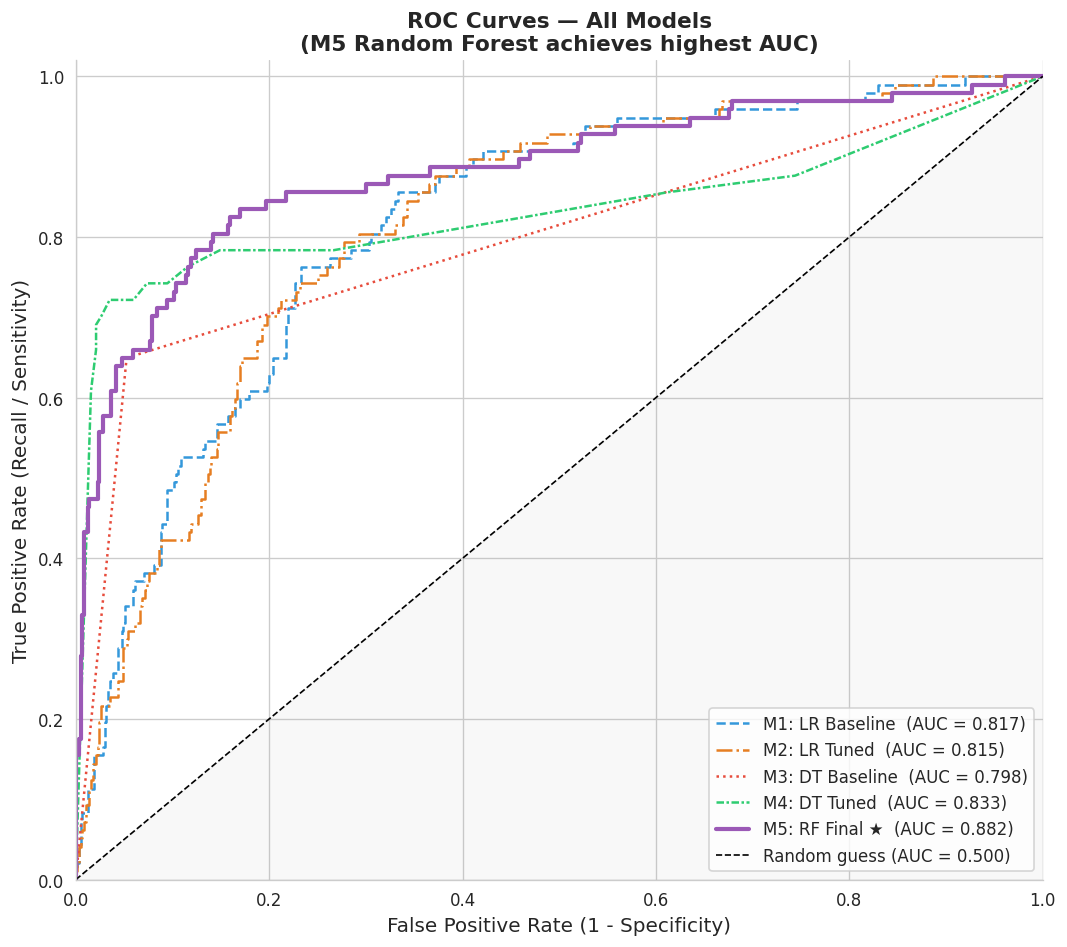

In [ ]:
# VISUAL 9: ROC Curves 
roc_colors = [C_BLUE, C_ORANGE, C_CHURN, C_RETAIN, C_PURPLE]
line_styles = ['--', '-.', ':', (0,(3,1,1,1)), '-']
lw_roc = [1.5, 1.5, 1.5, 1.5, 2.5]

fig, ax = plt.subplots(figsize=(9, 8))

for (model, Xte, label), color, ls, lw in zip(all_models, roc_colors, line_styles, lw_roc):
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw,
            label=f'{label}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random guess (AUC = 0.500)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models\n(M5 Random Forest achieves highest AUC)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.show()

### 5.4 Precision-Recall Curve — Final Model

For imbalanced datasets, the Precision-Recall (PR) curve is more informative than the ROC curve. It shows every recall level's achievable precision — the business can choose where on this curve to operate depending on team capacity.

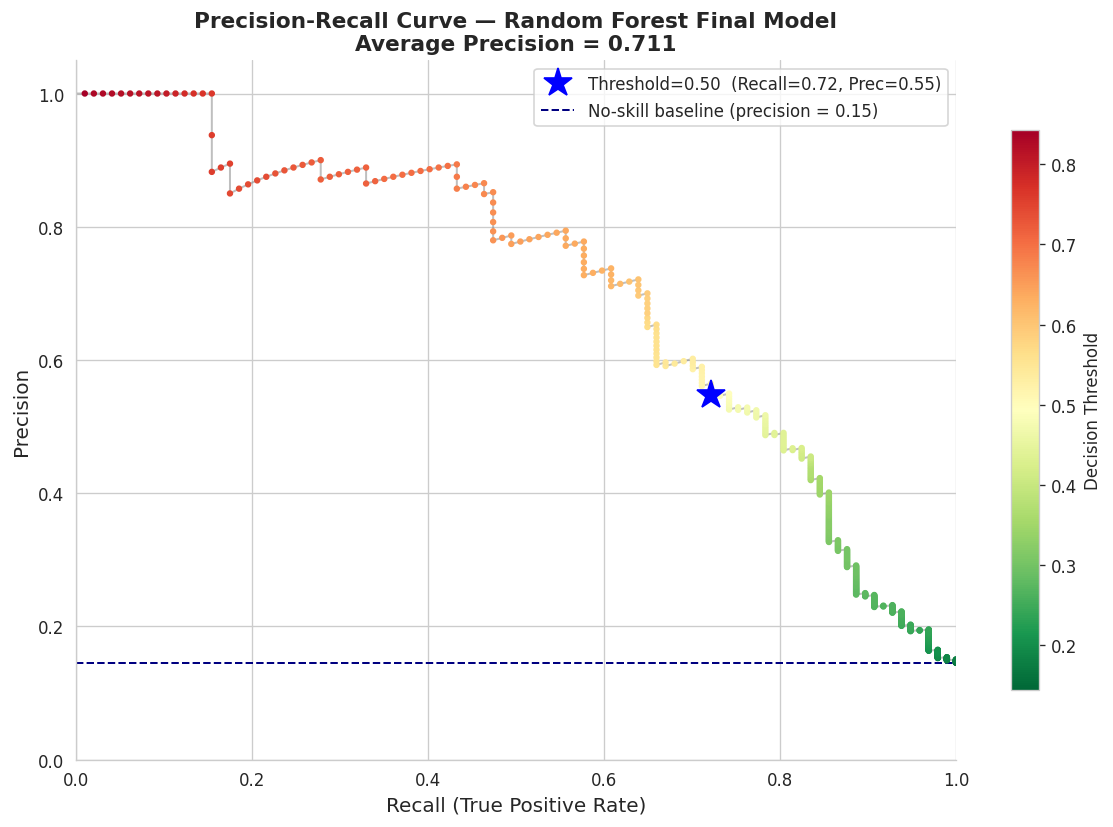

The colour gradient shows how the threshold changes along the curve.
Moving right (more recall) requires lowering the threshold → accepting lower precision.
The retention team can move the operating point based on their outreach capacity.


In [ ]:
#  VISUAL 10: Precision-Recall Curve — Final Model 
y_proba_rf = rf_final.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_rf)
avg_precision = average_precision_score(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(10, 7))

# PR curve coloured by threshold
sc = ax.scatter(recall_vals[:-1], precision_vals[:-1],
                c=thresholds, cmap='RdYlGn_r', s=8, zorder=3)
ax.plot(recall_vals, precision_vals, color='grey', linewidth=1.2,
        alpha=0.5, zorder=2)
plt.colorbar(sc, ax=ax, label='Decision Threshold', shrink=0.8)

# Mark default threshold (0.5)
idx_50 = np.argmin(np.abs(thresholds - 0.5))
ax.plot(recall_vals[idx_50], precision_vals[idx_50],
        'b*', markersize=18, label=f'Threshold=0.50  (Recall={recall_vals[idx_50]:.2f}, Prec={precision_vals[idx_50]:.2f})',
        zorder=5)

# No-skill baseline
no_skill = y_test.mean()
ax.axhline(y=no_skill, color='navy', linestyle='--', linewidth=1.2,
           label=f'No-skill baseline (precision = {no_skill:.2f})')

ax.set_xlabel('Recall (True Positive Rate)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curve — Random Forest Final Model\n'
             f'Average Precision = {avg_precision:.3f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout(); plt.show()

print('The colour gradient shows how the threshold changes along the curve.')
print('Moving right (more recall) requires lowering the threshold → accepting lower precision.')
print('The retention team can move the operating point based on their outreach capacity.')

### 5.5 Feature Importance — Lollipop Chart

A lollipop chart conveys the same ranked importance information as a bar chart but with much less visual clutter — the thin stem draws the eye to the dot without dominating the figure.

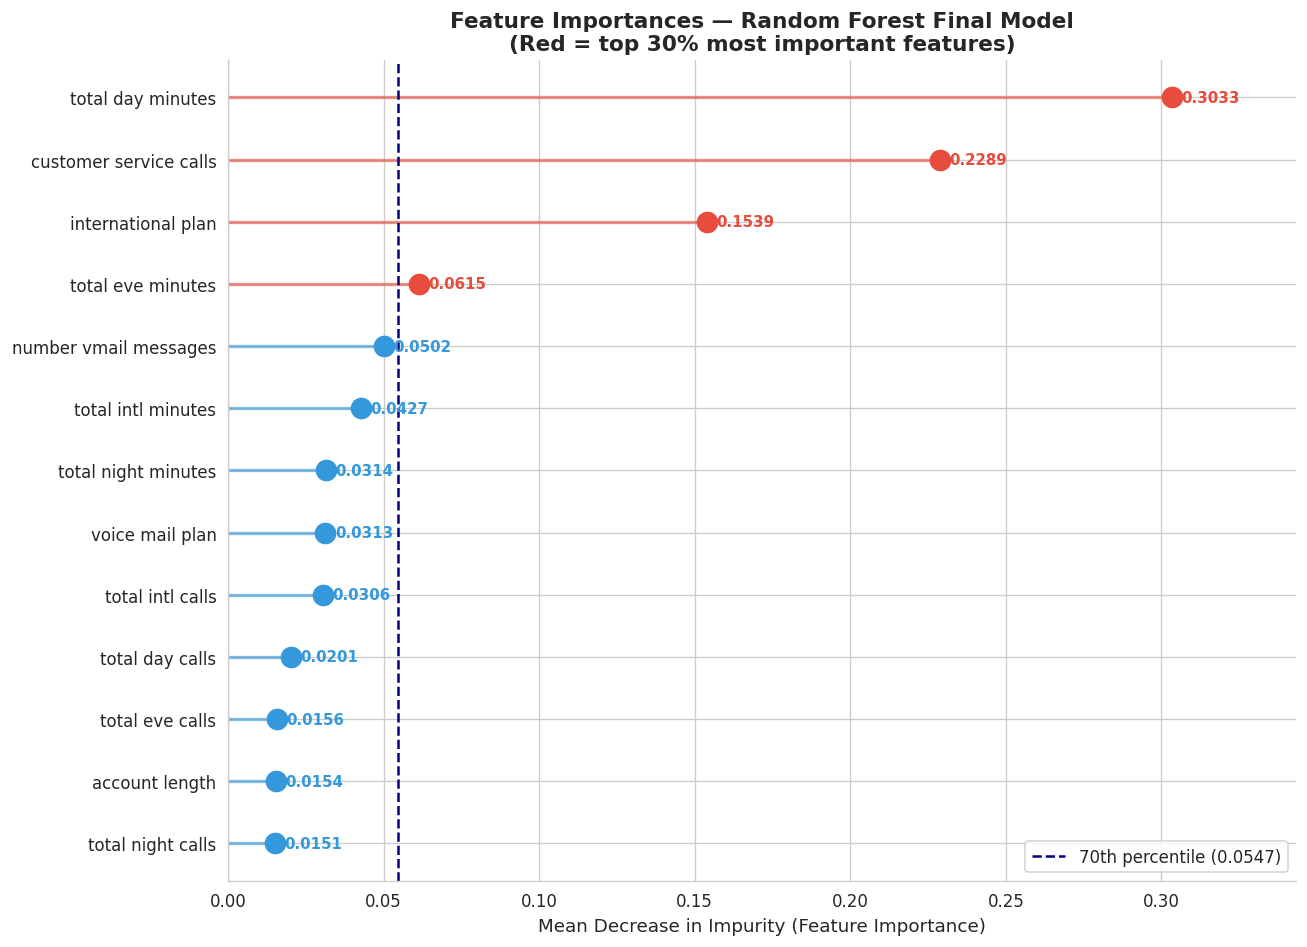

Top 5 features:
  total day minutes              0.3033
  customer service calls         0.2289
  international plan             0.1539
  total eve minutes              0.0615
  number vmail messages          0.0502


In [ ]:
#  VISUAL 11: Lollipop chart — feature importance 
importances = pd.Series(rf_final.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)
top_q = importances.quantile(0.70)

fig, ax = plt.subplots(figsize=(11, 8))

for i, (feat, val) in enumerate(importances.items()):
    color = C_CHURN if val >= top_q else C_BLUE
    ax.hlines(i, 0, val, linewidth=2, color=color, alpha=0.6)
    ax.plot(val, i, 'o', markersize=12, color=color, zorder=5)
    ax.text(val + 0.003, i, f'{val:.4f}',
            va='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(x=top_q, color='navy', linestyle='--', linewidth=1.5,
           label=f'70th percentile ({top_q:.4f})')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index, fontsize=10)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title('Feature Importances — Random Forest Final Model\n'
             '(Red = top 30% most important features)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, importances.max() + 0.04)
plt.tight_layout(); plt.show()

print('Top 5 features:')
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<30s} {val:.4f}')

### 5.6 Feature Importance — Treemap

A treemap presents feature importances as proportional rectangles — making the relative magnitude of each feature immediately visible at a glance.

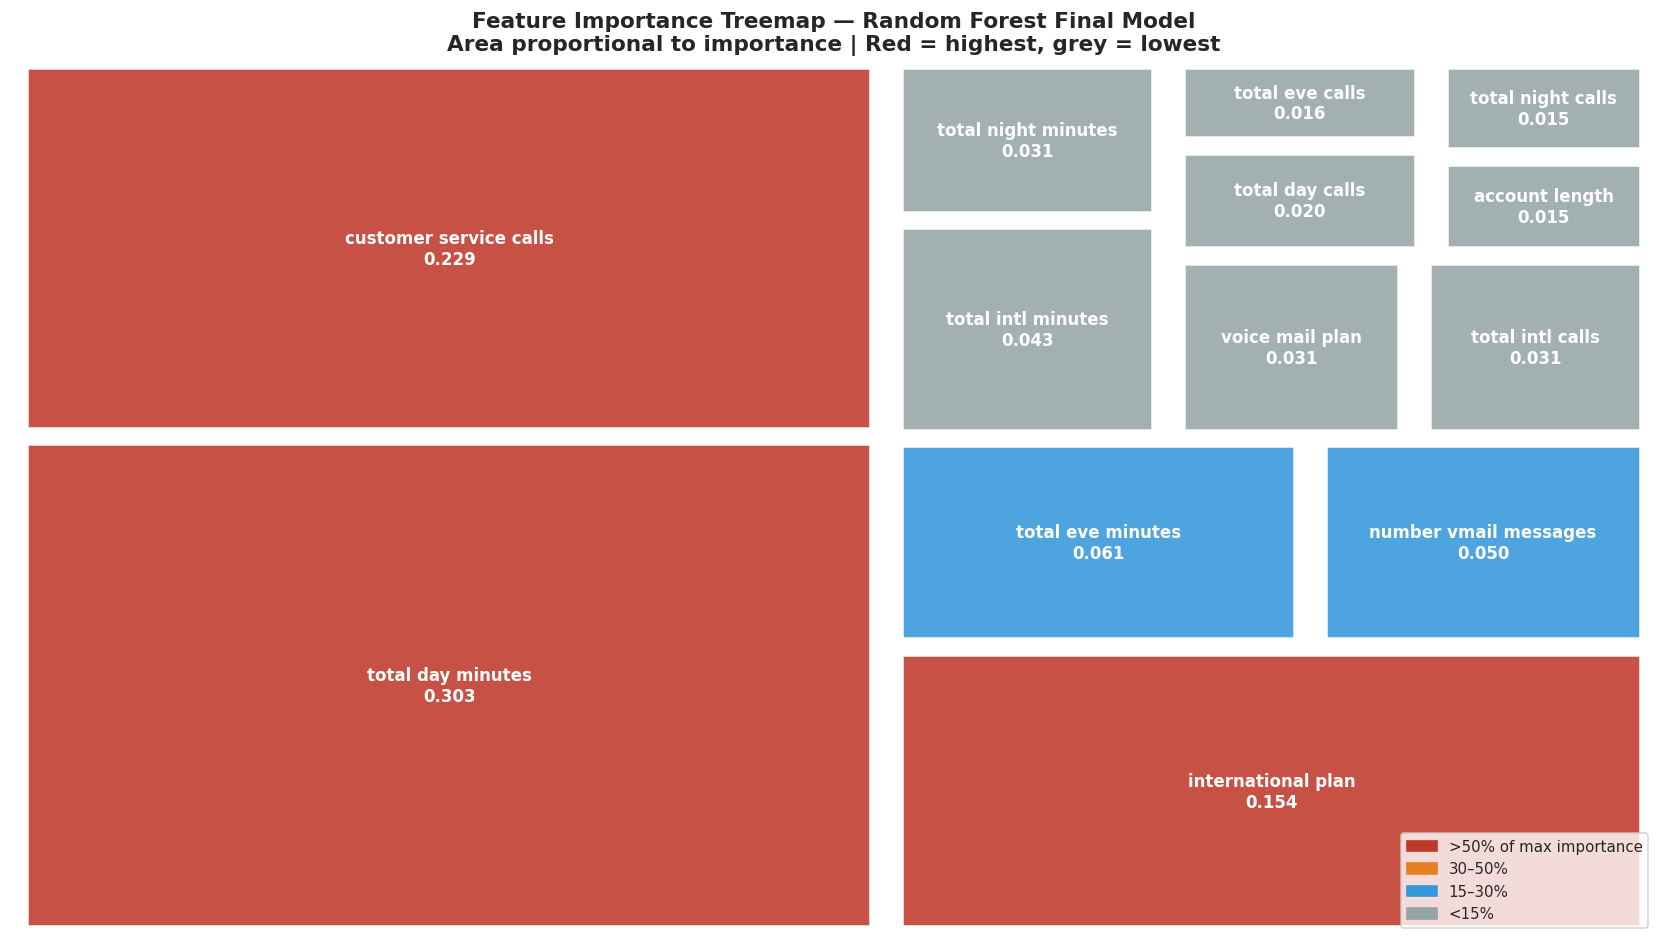

In [ ]:
#  VISUAL 12: Treemap — feature importance 
import squarify

imp_sorted = importances.sort_values(ascending=False)

# Colour by importance tier
def tier_color(v, max_v):
    ratio = v / max_v
    if ratio > 0.50: return '#c0392b'
    if ratio > 0.30: return '#e67e22'
    if ratio > 0.15: return '#3498db'
    return '#95a5a6'

colors_tm = [tier_color(v, imp_sorted.max()) for v in imp_sorted.values]
labels_tm = [f'{name}\n{val:.3f}' for name, val in imp_sorted.items()]

fig, ax = plt.subplots(figsize=(14, 8))
squarify.plot(
    sizes=imp_sorted.values,
    label=labels_tm,
    color=colors_tm,
    alpha=0.88,
    text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
    ax=ax,
    pad=True
)
ax.axis('off')
ax.set_title('Feature Importance Treemap — Random Forest Final Model\n'
             'Area proportional to importance | Red = highest, grey = lowest',
             fontsize=13, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color='#c0392b', label='>50% of max importance'),
    mpatches.Patch(color='#e67e22', label='30–50%'),
    mpatches.Patch(color='#3498db', label='15–30%'),
    mpatches.Patch(color='#95a5a6', label='<15%'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, frameon=True)
plt.tight_layout(); plt.show()

### 5.7 Final Model — Holdout Test Set Evaluation

In [ ]:
#  Final model metrics on holdout test set 
y_pred_final  = rf_final.predict(X_test)
y_proba_final = rf_final.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print('FINAL MODEL — HOLDOUT TEST SET RESULTS')
print('='*55)
print(f'Model:        Random Forest  (n_estimators=200, max_depth=5, class_weight=balanced)')
print(f'Test size:    {len(y_test):,} customers  ({y_test.sum()} churned | {len(y_test)-y_test.sum()} retained)')
print()
print(f'  True Positives  (churners caught):          {tp:>4}')
print(f'  False Negatives (churners missed):          {fn:>4}')
print(f'  False Positives (non-churners flagged):     {fp:>4}')
print(f'  True Negatives  (correctly cleared):        {tn:>4}')
print()
print(f'  Recall    : {recall_score(y_test,y_pred_final):.3f}   ({tp}/{y_test.sum()} churners identified)')
print(f'  Precision : {precision_score(y_test,y_pred_final):.3f}')
print(f'  F1-Score  : {f1_score(y_test,y_pred_final):.3f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test,y_proba_final):.3f}')
print()
print('Business translation:')
print(f'  Of {y_test.sum()} customers who would churn, the model correctly flags {tp} ({tp/y_test.sum()*100:.0f}%).')
print(f'  The retention team handles {fp} false alarms alongside {tp} real churners.')
print(f'  Roughly {precision_score(y_test,y_pred_final)*100:.0f}% of all flagged customers are genuine churn risks.')

FINAL MODEL — HOLDOUT TEST SET RESULTS
Model:        Random Forest  (n_estimators=200, max_depth=5, class_weight=balanced)
Test size:    667 customers  (97 churned | 570 retained)

  True Positives  (churners caught):            70
  False Negatives (churners missed):            27
  False Positives (non-churners flagged):       58
  True Negatives  (correctly cleared):         512

  Recall    : 0.722   (70/97 churners identified)
  Precision : 0.547
  F1-Score  : 0.622
  ROC-AUC   : 0.882

Business translation:
  Of 97 customers who would churn, the model correctly flags 70 (72%).
  The retention team handles 58 false alarms alongside 70 real churners.
  Roughly 55% of all flagged customers are genuine churn risks.


### 5.8 Final Model Selection Justification

| Criterion | M4: Decision Tree | **M5: Random Forest** | Verdict |
|-----------|:-----------------:|:---------------------:|--------|
| Test Recall | 0.742 | 0.722 | Within noise — tie |
| Test F1 | 0.673 | 0.622 | DT slightly higher |
| **Test AUC** | 0.833 | **0.882** | **RF significantly higher** |
| Train-test gap | 0.196 | **0.130** | **RF generalises better** |

**M5 (Random Forest) selected because:**
1. **ROC-AUC 0.882** — the retention team scores customers by *probability*, not binary predictions. AUC directly measures ranking quality at every threshold.
2. **Smallest overfitting gap (0.130)** — more reliable on truly unseen production data.
3. **Ensemble feature importances** — stable estimates averaged across 200 trees rather than a single tree's arbitrary splits.

---
## Phase 6: Conclusions, Recommendations & Deployment

### Key Feature Insights

| Rank | Feature | Business Implication | Recommended Action |
|------|---------|---------------------|--------------------|
| 1 | **Total day minutes** | Heavy users pay more → price-sensitive → higher churn | Offer loyalty rate caps for customers above 75th percentile (>216 min/day) |
| 2 | **Customer service calls** | 4+ calls signals deep dissatisfaction | Auto-flag after 3rd call; route to senior retention agent |
| 3 | **International plan** | 42.4% vs 11.5% churn — plan may be poor value | Audit pricing and coverage; conduct exit interviews |
| 4 | **Total eve minutes** | Secondary usage signal | Monitor alongside day minutes |
| 5 | **Total intl minutes** | High intl usage + intl plan = double churn risk | Offer discounted intl bundles to heavy intl users |

**Protective factor:** Voice mail plan holders churn at 8.7% vs 16.7% — consider offering it as a free retention incentive.

### Model Limitations

1. **No demographic or contract data** — age, income, and contract type are known churn drivers but absent.
2. **No timestamps** — cannot model churn as a time-to-event problem or detect seasonality.
3. **Static model** — must be retrained as pricing and competitive landscape evolve.
4. **27.8% missed churners** — the model still misses roughly 1 in 4 actual churners.
5. **45% false positive rate among flagged** — outreach cost for non-churners must be budgeted.

### Deployment Recommendations

- **Weekly scoring** — score all active accounts weekly; export priority-ranked list to CRM.
- **Adjustable threshold** — lower the probability threshold to catch more churners; raise it to reduce false alarms based on team capacity.
- **Quarterly retraining** — refresh the model on new data every quarter.
- **A/B test** — hold out a random control group of high-risk customers to measure true retention lift from model-driven outreach.